# **Introduction** <a name="introduction"></a>

This notebook will demonstrate the creation of a machine learning model while covering all features provided by IBM AI Factsheet. The demonstration will include key functionalities such as:

- **Trace and Customize Training Run:** Track and modify the training process to suit your specific needs.
- **Export Training Facts:** Export detailed information about the training process for further analysis.
- **Inventory Management:** Enable the creation and management of inventory items while supporting multiple users with varied roles for seamless collaboration in inventory management.
- **Additional Training Information:** Capture and manage supplementary data related to the training run.
- **Custom Facts:** Define and track custom facts that are important for your model's lifecycle.
- **Attachments:** Add and manage attachments related to the training process, such as datasets, logs, or reports.
- **Capture Cell Facts:** Capture and store facts directly from specific cells in your notebook.
- **Associate Workspaces:** Associate AI use cases with appropriate workspaces, ensuring they are organized around the same business problem. This involves setting up workspaces that will be used throughout the development process to tackle the business problem or implement the use case smoothly
- **Governing AI Assets:** Ensure proper governance of AI models, including compliance with regulations and policies.

For detailed documentation on these features, please refer to the [IBM AI Factsheet documentation](https://s3.us.cloud-object-storage.appdomain.cloud/factsheets-client/index.html).

#### **Tree Visualization with DtreeViz**
To visualize decision trees, you need to install the `dtreeviz` package. Detailed installation instructions can be found [here](https://github.com/parrt/dtreeviz).

**Required Services:**
- `watsonx.governance`
- `watsonx.ai`

**Required Packages:**
- **IBM Facts Client Python SDK (>=1.0.101)**
- **IBM-watsonx-ai Python SDK**


<a name="setupcloud"></a>

In [ ]:
!pip install -q dtreeviz
!pip install wget --quiet
!pip install -U python-dotenv --quiet
!pip install ibm-aigov-facts-client
!pip install -U ibm-watsonx-ai --quiet
!pip install wget --quiet

In [1]:
import warnings
import wget
import shutil
import time
from dotenv import load_dotenv
import os
from IPython.display import display, Markdown
from ibm_aigov_facts_client import AIGovFactsClient,CloudPakforDataConfig

warnings.filterwarnings('ignore')
shutil.rmtree('./mlruns', ignore_errors=True)
load_dotenv()

False


- Flag `run_cleanup_at_end` offers option to delete created assets at the end of the notebook.The notebook will show URL to UI for model and model use case at certain cells. By dafault we set it to `run_cleanup_at_end=False` so you can access UI and see the changes. If you decide to cleanup assets at the end, set `run_cleanup_at_end=True` and remember cells showing links to UI will `NOT` work in that case.

In [2]:
run_cleanup_at_end=True

- `Experiment` and `model names` can be customized.

- Model container type can be `space` or `project`

In [ ]:
MODEL_NAME="Iris Watsonx-ai Model"
experiment_name="External Model"
container_type="project"
container_id=os.getenv("CONTAINER_ID", "<if you can't use .env you can provide your value here>") # Project_id where the model has to store 

---
## Authentication Setup<a name="setup"></a>


### IBM watsonx.goverance software<a name="Watsonx.Gov-Platform"></a>

- Service url is the watsonx.goverance software platform host URL. For skytap environment, it would be the internal nginx URL.
- You can either use user `password` or platform `apikey` to authenticate

In [ ]:
creds=CloudPakforDataConfig(service_url=os.getenv("CPD_SERVICE_URL", "<if you can't use .env you can provide your value here>"),
        username=os.getenv("CPD_USERNAME", "<if you can't use .env you can provide your value here>"),
        password=os.getenv("CPD_PASSWORD", "<if you can't use .env you can provide your value here>"))


## Client Initialization
- Container type would be either `space` or `project`. To use get/set environment utilities, model asset should be stored in Space.
- If running this notebook multiple times with same experiment name or anytime face error saying `Experiment with same name already exists`, use `set_as_current_experiment=True` when initiating client





In [5]:

facts_client = AIGovFactsClient(cloud_pak_for_data_configs=creds,experiment_name= experiment_name, container_type=container_type,container_id=container_id, set_as_current_experiment=True)


2026/03/24 08:43:53 INFO : Experiment External Model does not exist, creating new experiment
2026/03/24 08:43:53 INFO : Experiment successfully created with ID 130070522608756146 and name External Model
2026/03/24 08:43:53 INFO : Autolog enabled Successfully


In [6]:
facts_client.version

'1.0.105'

---

## Create and Train Model <a name="#createmodel"></a>

- This sample code demonstrates creating and training a model, specifically a classifier.
- Model development is achieved without writing any IBM or watsonx.governance-specific code.
- Key training facts are automatically captured in the background and can be saved to a factsheet later.


In [7]:
import pandas as pd
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score
import numpy as np

## Get testdata for iris.
iris=datasets.load_iris()

x=iris.data
y=iris.target

## Split training and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.5)

### Train Model

The following code will be used to train the model. During the training process, key facts and metrics will be automatically captured in the background by the `IBM watsonx.governance` factsheets client. These facts can later be saved and reviewed in a factsheet.

**Note:** Although there is no need to include any specific `IBM watsonx.governance` code for this process, you will still observe output



In [8]:
## Train model
classifier=tree.DecisionTreeClassifier()
classifier.fit(x_train,y_train)

## Predict model
predictions=classifier.predict(x_test)

## Check accuracy for the model
print(accuracy_score(y_test,predictions))

2026/03/24 08:44:47 INFO : logging results to factsheet for run_id 79b2de088eda4402875aca369bef0d42
2026/03/24 08:44:49 INFO : Successfully logged results to Factsheet service for run_id 79b2de088eda4402875aca369bef0d42 under asset_id: e97bbe0c-aeee-4833-9971-28b480f98812 and project_id : 5a9854a6-04ed-4f52-a464-d75d04d267c1
0.9466666666666667


---
## Trace and Customize Training Runs<a name="extrametrics"></a>

Before saving the model, you have the option to log additional metrics, parameters, and tags associated with the run ID. If you prefer not to add any extra information, you can skip this section and proceed directly to the **Store Model** section.

For more details on logging additional information, refer to the [Basic Utilities Documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model/Basic%20Utilities.html#).




#### List all active experiments.


In [9]:
facts_client.experiments.list_experiments()

,experiment_id,name,tags,location
0,130070522608756146,External Model,{},file:///Users/tharayasmin/Documents/ai-governa...
1,0,Default,{},file:///Users/tharayasmin/Documents/ai-governa...


#### Retrieve Current Experiment ID


In [10]:
current_exp_ID = facts_client.experiments.get_current_experiment_id()
current_exp_ID


'130070522608756146'

In [11]:
facts_client.runs.list_runs_by_experiment(current_exp_ID)

,run_id,experiment_id,published,artifact_uri,start_time,end_time
0,79b2de088eda4402875aca369bef0d42,130070522608756146,True,file:///Users/tharayasmin/Documents/ai-governa...,2026-03-24 03:14:46.015000+00:00,2026-03-24 03:14:49.624000+00:00


#### Retrieve Current Run ID

In [12]:
current_run_ID = facts_client.runs.get_current_run_id()
current_run_ID

'79b2de088eda4402875aca369bef0d42'

#### <span style="color: gold;">Log Metrics, Parameters, and Tags for the Current Run</span>


In [13]:
facts_client.runs.log_metric(current_run_ID,"mae",0.77)
#facts_client.runs.log_metrics(current_run_ID,{"mse": 2000.00, "rmse": 50.00})

facts_client.runs.log_param(current_run_ID,"curve",1)
#facts_client.runs.log_params(current_run_ID,{"n_estimators": 3, "random_state": 42})

facts_client.runs.set_tags(current_run_ID, {"Notebook name": "sample notebook", "Notebook id": "sample_id"})


'Successfully set tags under run 79b2de088eda4402875aca369bef0d42'

#### Export Individual Run to Factsheet Service


In [14]:
facts_client.export_facts.export_payload(current_run_ID)

2026/03/24 08:44:49 INFO : Initiating logging to factsheet for run_id......79b2de088eda4402875aca369bef0d42
2026/03/24 08:44:52 INFO : Successfully logged results to Factsheet service for run_id 79b2de088eda4402875aca369bef0d42 under asset_id: e97bbe0c-aeee-4833-9971-28b480f98812 and project_id : 5a9854a6-04ed-4f52-a464-d75d04d267c1


---
## Store Model as a watsonx.ai / WML Asset in Project <a name="#savemodel"></a>

At present, the model exists solely as a Scikit-Learn object in memory. The subsequent step is to register it as a watsonx.ai / WML asset.


In [15]:
from ibm_watsonx_ai import APIClient
from ibm_watsonx_ai import Credentials


Credentials = {
                   "url": creds.url,
                   "username": creds.username,
                   "password" : creds.password,
                   "instance_id": "openshift",
                   "version" : "5.3"
                  }


In [16]:
watsonx_ai_client = APIClient(Credentials)
watsonx_ai_client.version
watsonx_ai_client.set.default_project(container_id)

'SUCCESS'

### Define and Prepare Model Metadata for watsonx.ai / WML

The following code defines the software specification and model properties, and prepares the model metadata for registration with watsonx.ai / WML.


In [17]:
software_spec_uid = watsonx_ai_client.software_specifications.get_id_by_name("runtime-25.1-py3.12")
print("Software Specification ID: {}".format(software_spec_uid))

model_props = {
    watsonx_ai_client._models.ConfigurationMetaNames.NAME:"{}".format(MODEL_NAME),
    watsonx_ai_client._models.ConfigurationMetaNames.TYPE: "scikit-learn_1.6",
    watsonx_ai_client._models.ConfigurationMetaNames.SOFTWARE_SPEC_UID: software_spec_uid,
    watsonx_ai_client._models.ConfigurationMetaNames.LABEL_FIELD:"target",
}

facts_client.export_facts.prepare_model_meta(wml_client=watsonx_ai_client,meta_props=model_props)



Software Specification ID: f47ae1c3-198e-5718-b59d-2ea471561e9e


{'name': 'Iris Watsonx-ai Model',
 'type': 'scikit-learn_1.6',
 'software_spec': 'f47ae1c3-198e-5718-b59d-2ea471561e9e',
 'label_column': 'target',
 'custom': {'experiment_id': '9512350fa31f4134b3d393e9a05faf31',
  'experiment_name': 'External Model'}}

### Store Model and Retrieve Model ID

The following code stores the model in watsonx.ai / WML and retrieves its unique model ID.


In [18]:
print("Storing model .....")

published_model_details = watsonx_ai_client.repository.store_model(model=classifier, meta_props=model_props, training_data=x_train, training_target=y_train)
model_id = watsonx_ai_client.repository.get_model_id(published_model_details)
print("Done")
print("Model ID: {}".format(model_id))

Storing model .....
Done
Model ID: c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9


---
## Retrieve Saved Model with Factsheet Client

The model, saved using watsonx.ai / WML methods, includes comprehensive training documentation in the factsheet. 
Although additional information can be manually added, such as diagrams, this is beyond the scope of this notebook.

For more information, refer to the [documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/AIGov/Retrive%20Model.html).

To associate the model with an AI use case, retrieve it using the `assets.get_model()` method:

- Use `verbose=True` for detailed information.
- Retrieve the model by `model_id` with:
  - facts_client.assets.`get_model(model_id=<wml_model_id>)`
  
  - facts_client.assets.`get_model(model_id=<wml_model_id>, container_type=<space_or_project>, container_id=<space_or_project_id>)`


In [19]:
watsonx_ai_model=facts_client.assets.get_model(wml_stored_model_details=published_model_details)
watsonx_ai_model.get_info(verbose=True)

2026/03/24 08:45:09 INFO : 
Current model Information:
  Asset ID       : c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
  Container Type : project
  Container ID   : 5a9854a6-04ed-4f52-a464-d75d04d267c1
  Facts Type     : modelfacts_user



{'name': 'Iris Watsonx-ai Model',
 'asset_type': 'wml_model',
 'url': 'https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/ml/models/c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9?projectid=5a9854a6-04ed-4f52-a464-d75d04d267c1&context=cpdaas',
 'asset_id': 'c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9',
 'container_type': 'project',
 'container_id': '5a9854a6-04ed-4f52-a464-d75d04d267c1',
 'facts_type': 'modelfacts_user'}

In [20]:
model_ui_url = watsonx_ai_model.get_info(verbose=True)["url"]
display(Markdown("[Click here to see the created model asset and it's factsheet in the UI](" + model_ui_url + ")"))

[Click here to see the created model asset and it's factsheet in the UI](https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/ml/models/c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9?projectid=5a9854a6-04ed-4f52-a464-d75d04d267c1&context=cpdaas)

---
## Inventory Management

This section focuses on the creation and management of inventory on the Watsonx.Governance platform.
The inventory is a view where you can define an AI use case to request a new model, and then track the model and related assets through its lifecycle


For more information, refer to the [Inventory Managment documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model%20Usecase/Inventory.html).

<h3 style="color:gold;">Create Inventory</h3>

This method is used to create an inventory item with a specified name and description.

In [21]:

inventory=facts_client.assets.create_inventory(name="New Inventory",description="testing")

-----------------------------------------------------------------------------------------------------------------------------
                                                  Inventory Creation Started                                                 
-----------------------------------------------------------------------------------------------------------------------------
2026/03/24 08:45:20 INFO : Inventory 'New Inventory' has been created successfully.
2026/03/24 08:45:20 INFO : Details:
  Inventory ID: 7014d629-4e63-4687-a0e4-a3e533d46ff9
  Inventory Name: New Inventory
  Description: testing
  Creator ID: 1000331001
  Creator Name: cpadmin



In [22]:
inventory.get_info()

{'inventory_id': '7014d629-4e63-4687-a0e4-a3e533d46ff9',
 'name': 'New Inventory',
 'description': 'testing',
 'creator': ('cpadmin', None),
 'creator_id': '1000331001'}

---

<h2>Inventory Collaborators</h2>

Inventories are inherently collaborative, allowing multiple users with distinct roles to participate in the inventory.

This section provides a detailed overview of the methods available for managing collaborators within each inventory item, including:

- Viewing the current list of collaborators
- Assigning new collaborators
- Defining roles for each collaborator
- Removing existing collaborators




<h3 style="color:gold;">Retrieve a list of collaborators for the inventory. </h3>

In [23]:
# Get the list of collaborators
inventory.list_collaborators()

-----------------------------------------------------------------------------------------------------------------------------
                                                Collaborator Retrieval Started                                               
-----------------------------------------------------------------------------------------------------------------------------
2026/03/19 14:43:22 INFO : Collaborators fetched successfully


[{'name': ('cpadmin', None),
  'user_id': '1000331001',
  'role': 'admin',
  'created_time': '2026-03-19T09:13:07Z'}]



<h3 style="color:gold;">Assigning New Collaborators</h3>

To add new collaborators, you need either the `user_id` or the `access_group_id`, depending on the platform you're using.

#### In the Watsonx.Gov Platform:
You need either the `user_id` or the `access_group_id`. To find these:

1. **Find the `user_id`:**
   - Go to the Watsonx.Gov Platform.
   - Navigate to **Access Control**.
   - Select **Users**.
   - Locate the `User-ID` for the desired user.

2. **Find the `access_group_id`:**
   - Go to the Watsonx.Gov Platform.
   - Navigate to **Access Control**.
   - Select **Users Group**.
   - Find the desired group.
   - The `access_group_id` is located at the end of the URL, e.g., `usermgmt-ui/groups/10001`, where `10001` is the group ID.




In [ ]:
# Determine user_id and access_group_id based on use_software flag

user_id = "1000000**"
access_group_id = "1000*"



In [ ]:
if user_id:
    inventory.add_collaborator(user_id=user_id, role="editor")
elif access_group_id:
    inventory.add_collaborator(access_group_id=access_group_id, role="editor")
else:
    raise ValueError("Either user_id or access_group_id must be provided")



---
## Creation of New AI Use Case <a href="#add_mut"></a>

An **AI Use Case** tracks model asset lifecycles across environments like development, pre-production, and production. 

**Note:** The term "AI Use Case" has replaced "Model Use Case" to reflect a broader range of AI assets. While some APIs may still use the old terminology, it will be phased out.


For more information, refer to the [New AI Use Case](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model%20Usecase/Creation%20of%20Model%20Uscase.html).

- If `ai_usecase_id` is not provided, the default inventory_id is used (requires `EDITOR` access).

- Retrieve the AI Use Case ID from the URL in inventory or by using `get_ai_usecase()`.

- For Cloud Pak for Data, ensure OpenPages integration is disabled (create inventory permission needed).


### Create AI usecase  <a name="createusecase"></a>

In [23]:
ai_usecase_inventory_id = inventory.get_id()
ai_usecase_name="Autmatic Iris classification"
ai_usecase_desc="AI usecase for iris classification"

In [25]:
ai_usecase = facts_client.assets.create_ai_usecase(catalog_id=ai_usecase_inventory_id,name=ai_usecase_name,description=ai_usecase_desc)
ai_usecase.get_info(True)

2026/03/24 08:50:55 INFO : AI usecase created successfully


{'ai_usecase_name': 'Autmatic Iris classification',
 'description': 'AI usecase for iris classification',
 'asset_type': 'model_entry',
 'url': 'https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/data/catalogs/7014d629-4e63-4687-a0e4-a3e533d46ff9/asset/47ae541c-d01a-4955-8670-836c1369601c?context=cpdaas',
 'model_usecase_id': '47ae541c-d01a-4955-8670-836c1369601c',
 'container_type': 'catalog',
 'catalog_id': '7014d629-4e63-4687-a0e4-a3e533d46ff9',
 'facts_type': 'model_entry_user'}

### Retrive AI usecase  <a name="createusecase"></a>

In [28]:
ai_usecase_id = os.getenv("ai_usecase_id", "<if you can't use .env you can provide your inventory id here>")
ai_usecase_inventory_id = os.getenv("INVENTORY_ID", "<if you can't use .env you can provide your inventory id here>")

ai_usecase_id = os.getenv("ai_usecase_id", "47ae541c-d01a-4955-8670-836c1369601c")
ai_usecase_inventory_id = os.getenv("INVENTORY_ID", "7014d629-4e63-4687-a0e4-a3e533d46ff9")



In [29]:
ai_usecase = facts_client.assets.get_ai_usecase(ai_usecase_id=ai_usecase_id,catalog_id=ai_usecase_inventory_id )


2026/03/24 08:52:37 INFO : 
Current AI Usecase Information:
  AI Usecase Name : Autmatic Iris classification
  Model Usecase ID: 47ae541c-d01a-4955-8670-836c1369601c
  Container Type  : catalog
  Catalog ID      : 7014d629-4e63-4687-a0e4-a3e533d46ff9
  Facts Type      : model_entry_user



In [30]:
ai_usecase.get_info(True)  

{'ai_usecase_name': 'Autmatic Iris classification',
 'description': 'AI usecase for iris classification',
 'asset_type': 'model_entry',
 'url': 'https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/data/catalogs/7014d629-4e63-4687-a0e4-a3e533d46ff9/asset/47ae541c-d01a-4955-8670-836c1369601c?context=cpdaas',
 'model_usecase_id': '47ae541c-d01a-4955-8670-836c1369601c',
 'container_type': 'catalog',
 'catalog_id': '7014d629-4e63-4687-a0e4-a3e533d46ff9',
 'facts_type': 'model_entry_user'}

In [31]:
print("Model usecase name is {}".format(ai_usecase.get_name()))
print("Model usecase ID is {}".format(ai_usecase.get_id()))

Model usecase name is Autmatic Iris classification
Model usecase ID is 47ae541c-d01a-4955-8670-836c1369601c


---
## Associated Workspace

Associate workspacesis employed to associate AI use cases with the appropriate workspaces, ensuring they are organized around the same business problem. This involves setting up workspaces that will be used throughout the development process to tackle the business problem or implement the use case smoothly.

For more information, refer to the [Associate Workspaces](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model%20Usecase/Associate%20Workspaces.html).


### Rules for Associating Workspaces

- A project can be associated with just one AI use case. Multiple projects might contribute assets or validations to a single AI use case, but each project is restricted to associating with a single-use case.

- A project can be associated with a single lifecycle phase for an AI use case. That is, you cannot use the same project to develop and validate an asset.

- A space can be associated with multiple AI use cases. That is, if you use a single space for deployed models in production, assets in that space might be tracked in different AI use cases. This distinction from how projects relate to an AI use case reflects how spaces are often used in ModelOps to manage a collection of deployments in a particular state.

`The following graphic illustrates the relationship of associated workspaces with an AI use case.`


<p align="center">
  <img src="https://dataplatform.cloud.ibm.com/docs/api/content/wsj/analyze-data/images/xgov-associate-workspace.svg?context=wx&locale=en" alt="Associate Workspace" style="width: 40%; max-width: 400px;">
</p>





<span style="color: gold; font-weight: bold;">**Note:** This feature is available in version 5.0.3 and above of the Cloud Pak for Data (CPD) release.</span>








### Retrieve All Associated Workspaces for the AI Use Case




In [32]:
ai_usecase.list_all_associated_workspaces()

model_usecase_id :47ae541c-d01a-4955-8670-836c1369601c ,catalog_id : 7014d629-4e63-4687-a0e4-a3e533d46ff9 
2026/03/24 08:52:50 INFO : Associated Workspaces retrieved successfully for the given AI usecase with id: 47ae541c-d01a-4955-8670-836c1369601c
2026/03/24 08:52:50 INFO : No associated workspaces found for the specified model_usecase_id: 47ae541c-d01a-4955-8670-836c1369601c


#### Add Project Workspace to AI Use Case

This feature allows you to link a project workspace to an AI use case, ensuring that all related tasks, data, and documentation are organized together for efficient development and management.


In [ ]:
# add project workspace to model usecase
ai_usecase.add_workspaces_associations(workspace_id=container_id, workspace_type="project", phase_name="develop")

In [ ]:
project_id2=os.getenv("CONTAINER_ID1", "<if you can't use .env you can provide your value here>") # Project_id where the model has to store 

In [ ]:
ai_usecase.add_workspaces_associations(workspace_id=project_id2, workspace_type="project", phase_name="develop")


#### Add Space Workspace to AI Use Case

This feature allows you to link a space workspace to an AI use case, ensuring that all related tasks, data, and documentation are organized together for efficient development and management.


In [ ]:
space_id=container_id=os.getenv("space_id", "<if you can't use .env you can provide your value here>") # Project_id where the model has to store 

ai_usecase.add_workspaces_associations(workspace_id=space_id, workspace_type="space", phase_name="operate")


In [34]:
ai_usecase.list_all_associated_workspaces()

model_usecase_id :47ae541c-d01a-4955-8670-836c1369601c ,catalog_id : 7014d629-4e63-4687-a0e4-a3e533d46ff9 
2026/03/24 08:53:14 INFO : Associated Workspaces retrieved successfully for the given AI usecase with id: 47ae541c-d01a-4955-8670-836c1369601c
2026/03/24 08:53:14 INFO : No associated workspaces found for the specified model_usecase_id: 47ae541c-d01a-4955-8670-836c1369601c


#### Retrieve All Associated Workspaces for the Use Case by Phase



In [35]:
ai_usecase.list_associated_workspaces_by_phase(phase_name="validate")


model_usecase_id :47ae541c-d01a-4955-8670-836c1369601c ,catalog_id : 7014d629-4e63-4687-a0e4-a3e533d46ff9 
2026/03/24 08:53:17 INFO : Associated Workspaces retrieved successfully for the given AI usecase with id: 47ae541c-d01a-4955-8670-836c1369601c
2026/03/24 08:53:17 INFO : No associated workspaces found for the specified model_usecase_id: 47ae541c-d01a-4955-8670-836c1369601c for the specified phase :validate


In [36]:
ai_usecase.list_associated_workspaces_by_phase(phase_name="develop")


model_usecase_id :47ae541c-d01a-4955-8670-836c1369601c ,catalog_id : 7014d629-4e63-4687-a0e4-a3e533d46ff9 
2026/03/24 08:53:21 INFO : Associated Workspaces retrieved successfully for the given AI usecase with id: 47ae541c-d01a-4955-8670-836c1369601c
2026/03/24 08:53:21 INFO : No associated workspaces found for the specified model_usecase_id: 47ae541c-d01a-4955-8670-836c1369601c for the specified phase :develop


#### Remove Workspace Association

This feature allows you to unlink a project workspace from an AI use case, effectively removing the association. This action helps to manage workspace assignments and maintain accurate project configurations by disassociating workspaces that are no longer relevant or needed.


In [ ]:
ai_usecase.remove_workspace_associations(workspace_ids=[project_id2,space_id])


In [ ]:
ai_usecase.remove_workspace_associations(workspace_ids=[container_id])


### Lookup of Workspaces

The **Lookup of Workspaces** feature allows you to efficiently retrieve information for multiple workspaces and projects in a single query. By specifying a list of identifiers and types, you can obtain details for various entities like projects and spaces, streamlining data retrieval and management.



In [35]:
workspace_info =[
                {"id": container_id, "type": "project"}
                ]

facts_client.assets.get_workspace_association_info(workspace_info=workspace_info)


		====Workspace Details:====
* workspace id: 5a9854a6-04ed-4f52-a464-d75d04d267c1
* workspace name: test_19/3
* workspace type: project
* phase name: Develop
* is valid: True

		====Associated Use Cases:====
  * ai usecase id : 58c4478f-aad0-4cd7-aa87-da3955854b26
  * ai usecase name: Autmatic Iris classification
  * inventory id: e89db651-8a14-4e22-9b26-4045b784fbf3
  * status: Draft
  * risk level: None

		====Tracked AI Assets:====
  No record found


{'associated_workspaces': [{'workspace_id': '5a9854a6-04ed-4f52-a464-d75d04d267c1',
   'workspace_type': 'project',
   'workspace_name': 'test_19/3',
   'phase_name': 'Develop',
   'is_valid': True,
   'associated_usecases': [{'ai_usecase_name': 'Autmatic Iris classification',
     'ai_usecase_id': '58c4478f-aad0-4cd7-aa87-da3955854b26',
     'inventory_id': 'e89db651-8a14-4e22-9b26-4045b784fbf3',
     'status': 'Draft',
     'risk_level': 'None',
     'owner_id': '1000331001',
     'description': 'AI usecase for iris classification'}],
   'tracked_assets': []}]}

---
## Working with Custom Facts <a name="customfactsdefmodel"></a>

- Ensure you have manage catalog permissions.
- Define the "slots" or "schema" by specifying the name, ID, and type for each fact slot you want to add to a model or ai use case.
- Custom facts definitions are global attributes visible in your account. By default, they are created under `modelfacts_user` for the model asset. Alternatively, use `model_entry_user` for definitions under a ai use case.
- Custom facts can be of type string, integer, or date.
- If defining a list of strings, set the attribute’s definition property `is_array` to True.
- For detailed information on options, refer to the [documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model/Model%20Custom%20Facts.html).


## <span style="color: gold;">Custom Facts for Model</span>

This section covers how to define custom facts for a model. Custom facts allow you to add specific, relevant information about your model that isn't covered by standard metrics or reports.


For detailed information on options, refer to the [documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model/Model%20Custom%20Facts.html).

In [38]:
!rm Asset_type_definition.csv
wget.download("https://raw.githubusercontent.com/IBM/ai-governance-factsheet-samples/main/Assets/data/Asset_type_definition.csv")

'Asset_type_definition.csv'

In [39]:
pd.read_csv('Asset_type_definition.csv')

,name,type,description,placeholder,is_array,required,hidden,readonly,default_value,label,minimum,maximum,min_length,max_length,is_searchable
0,TrainingData_Size,integer,Number of records in the training data,desc of userattrstr,False,True,False,False,0,TrainingData_Size,NaN,NaN,NaN,NaN,True
1,TrainingData_Ratio,string,Percentage of records in the training data,Percentage of records in the training data,False,True,False,False,0,TrainingData_Ratio,NaN,NaN,NaN,NaN,True
2,TestData_Size,integer,desc of userattrint,desc of userattrint,False,True,False,False,0,TestData_Size,NaN,NaN,NaN,NaN,False
3,TestData_Ratio,string,Percentage of records in the test data,Percentage of records in the test data,False,True,False,False,0,TestData_Ratio,NaN,NaN,NaN,NaN,True
4,Train_Class_Distributions,string,class distributions,class distributions,True,True,False,False,0,Train_Class_Distributions,NaN,NaN,NaN,NaN,False


### Add Custom Facts Defintion to Model.

This section describes how to add custom facts defintion or additional details defintion to a model. 

To include custom facts defintion in an Model, specify the type name as `modelfacts_user`. This ensures that the custom facts are accurately associated with the intended model.

**`overwrite`**: This optional parameter determines whether to merge the new definitions with or replace the existing properties. The default setting is `True`, which means that existing properties will be replaced by the new ones.










In [40]:
facts_client.assets.create_custom_facts_definitions("Asset_type_definition.csv",overwrite=True)
time.sleep(5)

2026/03/24 08:54:14 INFO : Creating definitions for type modelfacts_user
2026/03/24 08:54:17 INFO : Custom facts definitions updated Successfully


### Get Custom Facts Definitions <a name="getcustomfactsdefmodel"></a>

- Retrieves all custom fact definitions that have been set.
- Custom facts are defined globally and are available as slots on every model within the `same environment`.



In [41]:
facts_client.assets.get_facts_definitions(type_name="modelfacts_user")

{'description': 'The model fact user asset type to capture user defined attributes.',
 'fields': [{'key': 'TrainingData_Size',
   'type': 'integer',
   'facet': False,
   'is_array': False,
   'search_path': 'TrainingData_Size',
   'is_searchable_across_types': False},
  {'key': 'TrainingData_Ratio',
   'type': 'string',
   'facet': False,
   'is_array': False,
   'search_path': 'TrainingData_Ratio',
   'is_searchable_across_types': False},
  {'key': 'TestData_Ratio',
   'type': 'string',
   'facet': False,
   'is_array': False,
   'search_path': 'TestData_Ratio',
   'is_searchable_across_types': False}],
 'relationships': [],
 'properties': {'TestData_Size': {'type': 'integer',
   'description': 'desc of userattrint',
   'placeholder': 'desc of userattrint',
   'is_array': False,
   'required': True,
   'hidden': False,
   'readonly': False,
   'validated': False,
   'displayInChild': False,
   'restricted': False,
   'default_value': 0,
   'minimum': '',
   'maximum': '',
   'label':

### Set Custom Facts <a name="setfactsmodel"></a>

This function sets the values for the custom fact defined earlier.


In [42]:
watsonx_ai_model.set_custom_fact(fact_id="TrainingData_Size",value=5000)
watsonx_ai_model.set_custom_fact(fact_id="TrainingData_Ratio",value="70% of total")
watsonx_ai_model.set_custom_fact(fact_id="TestData_Size",value=1000)
watsonx_ai_model.set_custom_fact(fact_id="TestData_Ratio",value="30% of total")


		====Workspace Details:====
* workspace id: 5a9854a6-04ed-4f52-a464-d75d04d267c1
* workspace name: test_19/3
* workspace type: project
* phase name: Develop
* is valid: True

		====Associated Use Cases:====
  * ai usecase id : 58c4478f-aad0-4cd7-aa87-da3955854b26
  * ai usecase name: Autmatic Iris classification
  * inventory id: e89db651-8a14-4e22-9b26-4045b784fbf3
  * status: Draft
  * risk level: None

		====Tracked AI Assets:====
  No record found
2026/03/24 08:54:46 INFO : Custom fact TrainingData_Size successfully set to new value 5000

		====Workspace Details:====
* workspace id: 5a9854a6-04ed-4f52-a464-d75d04d267c1
* workspace name: test_19/3
* workspace type: project
* phase name: Develop
* is valid: True

		====Associated Use Cases:====
  * ai usecase id : 58c4478f-aad0-4cd7-aa87-da3955854b26
  * ai usecase name: Autmatic Iris classification
  * inventory id: e89db651-8a14-4e22-9b26-4045b784fbf3
  * status: Draft
  * risk level: None

		====Tracked AI Assets:====
  No recor

- The `Train_Class_Distributions` attribute should have the `is_array` property set to `True` in the fact definition, which allows it to accept either a single string or a list of strings.


In [43]:
watsonx_ai_model.set_custom_fact(fact_id="Train_Class_Distributions",value=["Risk 30%","No Risk 70%"])


		====Workspace Details:====
* workspace id: 5a9854a6-04ed-4f52-a464-d75d04d267c1
* workspace name: test_19/3
* workspace type: project
* phase name: Develop
* is valid: True

		====Associated Use Cases:====
  * ai usecase id : 58c4478f-aad0-4cd7-aa87-da3955854b26
  * ai usecase name: Autmatic Iris classification
  * inventory id: e89db651-8a14-4e22-9b26-4045b784fbf3
  * status: Draft
  * risk level: None

		====Tracked AI Assets:====
  No record found
2026/03/24 08:56:11 INFO : Custom fact Train_Class_Distributions successfully set to new value ['Risk 30%', 'No Risk 70%']


##### Multiple Facts Can Be Set or Updated Simultaneously; Existing Values Will Be Replaced


In [44]:
watsonx_ai_model.set_custom_facts({"TestData_Size": 1500, "TrainingData_Size": 5000, "Train_Class_Distributions":["Risk 35%","No Risk 65%"]})


		====Workspace Details:====
* workspace id: 5a9854a6-04ed-4f52-a464-d75d04d267c1
* workspace name: test_19/3
* workspace type: project
* phase name: Develop
* is valid: True

		====Associated Use Cases:====
  * ai usecase id : 58c4478f-aad0-4cd7-aa87-da3955854b26
  * ai usecase name: Autmatic Iris classification
  * inventory id: e89db651-8a14-4e22-9b26-4045b784fbf3
  * status: Draft
  * risk level: None

		====Tracked AI Assets:====
  No record found
2026/03/24 08:56:51 INFO : Custom facts ['TrainingData_Size', 'TestData_Size', 'Train_Class_Distributions'] successfully set to values [1500, 5000, ['Risk 35%', 'No Risk 65%']]


### Get Custom Facts <a name="getfactsmodel"></a>

Retrieve all custom facts or a specific fact by its name as defined in the facts definitions. 

You can also view the custom facts set via the UI by running `external_model.get_info(verbose=True)["url"]` to get the URL.


In [45]:
ui_url = watsonx_ai_model.get_info(verbose=True)["url"]
display(Markdown("[Click here to see the external model and it's custom fact values in the UI](" + ui_url + ")"))

[Click here to see the external model and it's custom fact values in the UI](https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/ml/models/c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9?projectid=5a9854a6-04ed-4f52-a464-d75d04d267c1&context=cpdaas)

#### Get custom fact value/s by id

In [46]:
watsonx_ai_model.get_custom_fact_by_id(fact_id="TrainingData_Size")

5000

#### Get all defined custom facts for Model

In [47]:
watsonx_ai_model.get_custom_facts()

{'TestData_Size': 1500,
 'TestData_Ratio': '30% of total',
 'TrainingData_Size': 5000,
 'TrainingData_Ratio': '70% of total',
 'Train_Class_Distributions': ['Risk 35%', 'No Risk 65%']}

#### Get all facts related to asset.

In [48]:
watsonx_ai_model.get_all_facts()

https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/v2/assets/c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9?project_id=5a9854a6-04ed-4f52-a464-d75d04d267c1


{'metadata': {'project_id': '5a9854a6-04ed-4f52-a464-d75d04d267c1',
  'sandbox_id': '5a9854a6-04ed-4f52-a464-d75d04d267c1',
  'usage': {'last_updated_at': '2026-03-24T03:26:51Z',
   'last_updater_id': '1000331001',
   'last_update_time': 1774322811627,
   'last_accessed_at': '2026-03-24T03:26:51Z',
   'last_access_time': 1774322811627,
   'last_accessor_id': '1000331001',
   'access_count': 0},
  'rov': {'mode': 0,
   'collaborator_ids': {},
   'member_roles': {'1000331001': {'user_iam_id': '1000331001',
     'roles': ['OWNER']}}},
  'is_linked_with_sub_container': False,
  'name': 'Iris Watsonx-ai Model',
  'asset_type': 'wml_model',
  'origin_country': 'us',
  'resource_key': '34c08b34-e684-4132-b487-284847bed89c',
  'rating': 0.0,
  'total_ratings': 0,
  'catalog_id': 'e6fe3b9a-51fa-40fb-b858-3b869f51fb30',
  'created': 1774322097855,
  'created_at': '2026-03-24T03:14:57Z',
  'owner_id': '1000331001',
  'size': 1298,
  'version': 2.0,
  'asset_state': 'available',
  'asset_attribute

#### Get custom facts by asset type<a name="get_allfactsmodel"></a> 
- You can get all facts of all types (`modelfacts_user` or `model_entry_user`) or filter by any fact type.

In [49]:
watsonx_ai_model.get_facts_by_type()


https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/v2/assets/c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9?project_id=5a9854a6-04ed-4f52-a464-d75d04d267c1


{'TestData_Size': 1500,
 'TestData_Ratio': '30% of total',
 'TrainingData_Size': 5000,
 'TrainingData_Ratio': '70% of total',
 'Train_Class_Distributions': ['Risk 35%', 'No Risk 65%']}

In [50]:
watsonx_ai_model.get_facts_by_type(facts_type="modelfacts_system")

https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/v2/assets/c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9?project_id=5a9854a6-04ed-4f52-a464-d75d04d267c1


{'source': '',
 'project_details': {'environment_type': 'development',
  'is_environmenttype_openscale_value': False},
 'model_information': {'algorithm': '',
  'input_type': '',
  'software_spec': '',
  'prediction_type': '',
  'software_spec_id': ''},
 'training_information': {'features': 4,
  'hyper_parameters': '',
  'training_data_references': [{'id': '1',
    'type': 'External data asset (File System)',
    'source': '',
    'source_href': '',
    'source_path': '',
    'source_type': '',
    'source_exists': True,
    'training_data': '',
    'training_data_href': '',
    'training_data_exists': True}]},
 'model_identity_information': {'model_identity_key': '34c08b34-e684-4132-b487-284847bed89c'}}

In [51]:
watsonx_ai_model.get_facts_by_type(facts_type="modelfacts_user")

https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/v2/assets/c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9?project_id=5a9854a6-04ed-4f52-a464-d75d04d267c1


{'TestData_Size': 1500,
 'TestData_Ratio': '30% of total',
 'TrainingData_Size': 5000,
 'TrainingData_Ratio': '70% of total',
 'Train_Class_Distributions': ['Risk 35%', 'No Risk 65%']}

### Remove Custom Facts <a name="removefactsmodel"></a>

Remove one or multiple facts using their associated fact IDs. This action does not delete the attribute itself but removes the associated value(s).


In [52]:
watsonx_ai_model.remove_custom_fact(fact_id="TrainingData_Size")

2026/03/24 08:57:25 INFO :  Value of Fact id TrainingData_Size removed successfully


#### Remove multiple custom facts

In [53]:
watsonx_ai_model.remove_custom_facts(fact_ids=["TrainingData_Ratio","TestData_Size","TestData_Ratio","Train_Class_Distributions"])

2026/03/24 08:57:54 INFO : Values of Fact ids ['TrainingData_Ratio', 'TestData_Size', 'TestData_Ratio', 'Train_Class_Distributions'] removed successfully


In [54]:
ui_url = watsonx_ai_model.get_info(verbose=True)["url"]
display(Markdown("[Click here to see the external model and it's custom fact values after removing ids in the UI](" + ui_url + ")"))

[Click here to see the external model and it's custom fact values after removing ids in the UI](https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/ml/models/c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9?projectid=5a9854a6-04ed-4f52-a464-d75d04d267c1&context=cpdaas)

## <span style="color: gold;">Custom Facts for AI usecase</span>

This section covers how to define custom facts for a ai usecase. Custom facts allow you to add specific, relevant information about your ai usecase that isn't covered by standard metrics or reports.

For detailed information on options, refer to the [documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model%20Usecase/Model%20Usecase%20Custom%20Facts.html).


In [55]:
!rm Asset_type_definition_me.csv
wget.download("https://raw.githubusercontent.com/IBM/ai-governance-factsheet-samples/main/Assets/data/Asset_type_definition_me.csv")

'Asset_type_definition_me.csv'

In [56]:
pd.read_csv('Asset_type_definition_me.csv')

,name,type,description,placeholder,is_array,required,hidden,readonly,default_value,label,minimum,maximum,min_length,max_length,is_searchable
0,model_scope,string,Model Scope,Model Scope,False,True,False,False,NaN,Model Scope,NaN,NaN,2,1000,True
1,model_purpose,string,Model Purpose,Model Purpose,False,True,False,False,NaN,Model Purpose,NaN,NaN,5,1000,True
2,model_use,string,Model Use,Model Use,True,True,False,False,NaN,Model Use,NaN,NaN,5,500,True
3,model_sponsor,string,Model Sponsor,Model Sponsor,False,True,False,False,NaN,Model Sponsor,NaN,NaN,5,200,True


### Add Custom Facts Defintion to  AI Use Case

This section describes how to add custom facts defintion or additional details defintion to a  AI use case. 

To include custom facts defintion in an AI use case, specify the type name as `model_entry_user`. This ensures that the custom facts are accurately associated with the intended model or AI use case.

**`overwrite`**: This optional parameter determines whether to merge the new definitions with or replace the existing properties. The default setting is `True`, which means that existing properties will be replaced by the new ones.










In [57]:
facts_client.assets.create_custom_facts_definitions(csvFilePath="Asset_type_definition_me.csv",section_name="Custom Model Details Title", type_name="model_entry_user")
time.sleep(5)

2026/03/24 08:57:58 INFO : Creating definitions for type model_entry_user
2026/03/24 08:58:01 INFO : Custom facts definitions updated Successfully


### Get Custom Facts Definitions <a name="getcustomfactsdefmodel"></a>

- Retrieves all custom fact definitions that have been set.
- Custom facts are defined globally and are available as slots on every model within the `same environment`.



In [58]:
facts_client.assets.get_facts_definitions(type_name="model_entry_user")

{'description': 'The model fact user asset type to capture user defined attributes.',
 'fields': [{'key': 'model_scope',
   'type': 'string',
   'facet': False,
   'is_array': False,
   'search_path': 'model_scope',
   'is_searchable_across_types': False},
  {'key': 'model_purpose',
   'type': 'string',
   'facet': False,
   'is_array': False,
   'search_path': 'model_purpose',
   'is_searchable_across_types': False},
  {'key': 'model_use',
   'type': 'string',
   'facet': False,
   'is_array': True,
   'search_path': 'model_use',
   'is_searchable_across_types': False},
  {'key': 'model_sponsor',
   'type': 'string',
   'facet': False,
   'is_array': False,
   'search_path': 'model_sponsor',
   'is_searchable_across_types': False}],
 'relationships': [],
 'properties': {'model_use': {'type': 'string',
   'description': 'Model Use',
   'placeholder': 'Model Use',
   'is_array': True,
   'required': True,
   'hidden': False,
   'readonly': False,
   'validated': False,
   'displayInChil

### Set Custom Facts <a name="setfactsmodel"></a>

This function sets the values for the custom fact defined earlier.


In [59]:
ai_usecase.set_custom_fact(fact_id="model_scope",value="Internal systems")
ai_usecase.set_custom_fact(fact_id="model_purpose",value="Predicting risk factor when giving loans")
ai_usecase.set_custom_fact(fact_id="model_sponsor",value="IBM")

2026/03/24 08:58:11 INFO : Custom fact model_scope successfully set to new value Internal systems
2026/03/24 08:58:14 INFO : Custom fact model_purpose successfully set to new value Predicting risk factor when giving loans
2026/03/24 08:58:17 INFO : Custom fact model_sponsor successfully set to new value IBM


##### Multiple Facts Can Be Set or Updated Simultaneously; Existing Values Will Be Replaced


In [60]:
ai_usecase.set_custom_fact(fact_id="model_use",value=["Determining risk factors","Client debt collections"])

2026/03/24 08:58:37 INFO : Custom fact model_use successfully set to new value ['Determining risk factors', 'Client debt collections']


### Get Custom Facts <a name="getfactsmodel"></a>

Retrieve all custom facts or a specific fact by its name as defined in the facts definitions. 

You can also view the custom facts set via the UI by running `external_model.get_info(verbose=True)["url"]` to get the URL.


In [61]:
ui_url = ai_usecase.get_info(verbose=True)["url"]
display(Markdown("[Click here to see the external model and it's custom fact values in the UI](" + ui_url + ")"))

[Click here to see the external model and it's custom fact values in the UI](https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/data/catalogs/7014d629-4e63-4687-a0e4-a3e533d46ff9/asset/47ae541c-d01a-4955-8670-836c1369601c?context=cpdaas)

#### Get custom fact value/s by id

In [62]:
ai_usecase.get_custom_fact_by_id(fact_id="model_scope")

'Internal systems'

#### Get all defined custom facts for modelfacts_user fact type

In [63]:
ai_usecase.get_custom_facts()

{'purpose': '',
 'model_use': ['Determining risk factors', 'Client debt collections'],
 'model_scope': 'Internal systems',
 'documentation': '',
 'model_purpose': 'Predicting risk factor when giving loans',
 'model_sponsor': 'IBM'}

#### Get all facts related to asset.

In [64]:
ai_usecase.get_all_facts()

{'metadata': {'usage': {'last_updated_at': '2026-03-24T03:28:37Z',
   'last_updater_id': '1000331001',
   'last_update_time': 1774322917588,
   'last_accessed_at': '2026-03-24T03:28:37Z',
   'last_access_time': 1774322917588,
   'last_accessor_id': '1000331001',
   'access_count': 0},
  'rov': {'mode': 0,
   'collaborator_ids': {'1000331001': {'user_iam_id': '1000331001'}},
   'member_roles': {'1000331001': {'user_iam_id': '1000331001',
     'roles': ['OWNER', 'EDITOR']}}},
  'is_linked_with_sub_container': False,
  'name': 'Autmatic Iris classification',
  'description': 'AI usecase for iris classification',
  'tags': [],
  'asset_type': 'model_entry',
  'origin_country': 'us',
  'rating': 0.0,
  'total_ratings': 0,
  'catalog_id': '7014d629-4e63-4687-a0e4-a3e533d46ff9',
  'created': 1774322455222,
  'created_at': '2026-03-24T03:20:55Z',
  'owner_id': '1000331001',
  'size': 0,
  'version': 2.0,
  'asset_state': 'available',
  'asset_attributes': ['model_entry', 'model_entry_user', 'm

#### Get custom facts by asset type<a name="get_allfactsmodel"></a> 
- You can get all facts of all types (`modelfacts_user` or `model_entry_user`) or filter by any fact type.

In [65]:
ai_usecase.get_facts_by_type()


{'purpose': '',
 'model_use': ['Determining risk factors', 'Client debt collections'],
 'model_scope': 'Internal systems',
 'documentation': '',
 'model_purpose': 'Predicting risk factor when giving loans',
 'model_sponsor': 'IBM'}

In [66]:
ai_usecase.get_facts_by_type(facts_type="model_entry_user")

{'purpose': '',
 'model_use': ['Determining risk factors', 'Client debt collections'],
 'model_scope': 'Internal systems',
 'documentation': '',
 'model_purpose': 'Predicting risk factor when giving loans',
 'model_sponsor': 'IBM'}

### Remove Custom Facts <a name="removefactsmodel"></a>

Remove one or multiple facts using their associated fact IDs. This action does not delete the attribute itself but removes the associated value(s).


In [67]:
ai_usecase.remove_custom_fact(fact_id="model_scope")

2026/03/24 08:59:06 INFO :  Value of Fact id model_scope removed successfully


#### Remove multiple custom facts

In [68]:
ai_usecase.remove_custom_facts(fact_ids=["model_purpose","model_sponsor","model_use"])

2026/03/24 08:59:10 INFO : Values of Fact ids ['model_purpose', 'model_sponsor', 'model_use'] removed successfully


In [69]:
ui_url = watsonx_ai_model.get_info(verbose=True)["url"]
display(Markdown("[Click here to see the external model and it's custom fact values after removing ids in the UI](" + ui_url + ")"))

[Click here to see the external model and it's custom fact values after removing ids in the UI](https://cpd-cpd-instance.apps.fsqa-530-497.cp.fyre.ibm.com/ml/models/c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9?projectid=5a9854a6-04ed-4f52-a464-d75d04d267c1&context=cpdaas)

---
## Additional Training Information <a name="custommetrics"></a>

Customize additional metrics, parameters, and tags associated with `run_id` in the current experiment after saving the model.

- The new functions offer a convenient way to set custom metrics, parameters, and tags. They also provide control over which of the potentially multiple runs these attributes are applied to. Custom metrics, parameters, and tags can be added once the model/external model is saved

- Supported only for `predictive models`, not for `prompt template asset` 


For more information, refer to the [Additional Training Information documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model/Model%20Experiment.html)


In [70]:
exp=watsonx_ai_model.get_experiment()
exp.get_info()

{'exp_id': '9512350fa31f4134b3d393e9a05faf31',
 'exp_name': 'External Model',
 'asset_id': 'c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9',
 'container_id': '5a9854a6-04ed-4f52-a464-d75d04d267c1',
 'container_type': 'project'}

#### Get all runs available in notebook experiment

In [71]:
all_runs = exp.get_all_runs()
print("Number of runs: {}".format(len(all_runs)))
all_runs

Number of runs: 2


[{'tags': [{'key': 'estimator_class',
    'value': 'sklearn.tree._classes.DecisionTreeClassifier'},
   {'key': 'facts.user', 'value': 'tharayasmin'},
   {'key': 'estimator_name', 'value': 'DecisionTreeClassifier'},
   {'key': 'facts.runName', 'value': 'crawling-skink-180'},
   {'key': 'facts.autologging', 'value': 'sklearn'},
   {'key': 'facts.source.name',
    'value': '/Users/tharayasmin/miniforge3/envs/py311/lib/python3.11/site-packages/ipykernel_launcher.py'},
   {'key': 'facts.source.type', 'value': 'LOCAL'}],
  'params': [{'key': 'max_depth', 'value': 'None'},
   {'key': 'min_weight_fraction_leaf', 'value': '0.0'},
   {'key': 'splitter', 'value': 'best'},
   {'key': 'max_leaf_nodes', 'value': 'None'},
   {'key': 'class_weight', 'value': 'None'},
   {'key': 'min_samples_leaf', 'value': '1'},
   {'key': 'random_state', 'value': 'None'},
   {'key': 'min_impurity_decrease', 'value': '0.0'},
   {'key': 'criterion', 'value': 'gini'},
   {'key': 'ccp_alpha', 'value': '0.0'},
   {'key': 

#### Get run object available in notebook experiment

In [72]:
run_id=all_runs[len(all_runs)-1].get("run_id")

if run_id:
    run=exp.get_run(run_id=run_id)
else:
    run=exp.get_run()
run.get_info()

{'run_id': '79b2de088eda4402875aca369bef0d42',
 'run_date': '24/03/2026 08:44:49',
 'metrics': [{'key': 'training_score', 'value': '1.0'},
  {'key': 'training_roc_auc', 'value': '1.0'},
  {'key': 'accuracy_score_x_test', 'value': '0.9466666666666667'},
  {'key': 'training_accuracy_score', 'value': '1.0'},
  {'key': 'mae', 'value': '0.77'},
  {'key': 'training_precision_score', 'value': '1.0'},
  {'key': 'training_log_loss', 'value': '4.440892098500627e-16'},
  {'key': 'training_f1_score', 'value': '1.0'},
  {'key': 'training_recall_score', 'value': '1.0'}],
 'params': [{'key': 'max_depth', 'value': 'None'},
  {'key': 'min_weight_fraction_leaf', 'value': '0.0'},
  {'key': 'curve', 'value': '1'},
  {'key': 'splitter', 'value': 'best'},
  {'key': 'max_leaf_nodes', 'value': 'None'},
  {'key': 'class_weight', 'value': 'None'},
  {'key': 'min_samples_leaf', 'value': '1'},
  {'key': 'random_state', 'value': 'None'},
  {'key': 'min_impurity_decrease', 'value': '0.0'},
  {'key': 'criterion', 'v

### Set Custom Metrics, Parameters, and Tags

This section explains how to add custom metrics, parameters, and tags to a model or AI use case after fetching the current `run` instance.









In [73]:
run.set_custom_metric(metric_id="test_metric_1",value=0.90)

2026/03/24 09:00:07 INFO : Set custom metric test_metric_1 successfully to value 0.9


In [74]:
run.set_custom_metrics(metrics_dict={"test_metric_2":0.95, "test_metric_3":0.91})

2026/03/24 09:00:40 INFO : Set custom metrics successfully.
2026/03/24 09:00:48 WARNING : OP is not enabled, cannot sync notebook experiment facts


In [75]:
run.set_custom_param(param_id="test_param_1",value="2")

2026/03/24 09:01:09 INFO : Set custom param test_param_1 successfully to value 2


In [76]:
run.set_custom_params(params_dict={"test_param_2":1.95, "test_param_2":1.91})

2026/03/24 09:01:42 INFO : Set custom params successfully
2026/03/24 09:01:51 WARNING : OP is not enabled, cannot sync notebook experiment facts


In [77]:
run.set_custom_tag(tag_id="test_tag_1",value="test tag value")

2026/03/24 09:02:11 INFO : Set custom tag test_tag_1 successfully to value test tag value


In [78]:
run.set_custom_tags(tags_dict={"test_tag_2":"test tag value2", "test_tag_3":"test tag value3"})

2026/03/24 09:02:44 INFO : Set custom tags successfully to values
2026/03/24 09:02:44 INFO : Successfully synced with CAMS
2026/03/24 09:02:53 WARNING : OP is not enabled, cannot sync notebook experiment facts


In [79]:
run_id=all_runs[len(all_runs)-1].get("run_id")
run=exp.get_run(run_id=run_id)
run.get_info()

{'run_id': '79b2de088eda4402875aca369bef0d42',
 'run_date': '24/03/2026 08:44:49',
 'metrics': [{'key': 'training_score', 'value': '1.0'},
  {'key': 'training_roc_auc', 'value': '1.0'},
  {'key': 'accuracy_score_x_test', 'value': '0.9466666666666667'},
  {'key': 'training_accuracy_score', 'value': '1.0'},
  {'key': 'mae', 'value': '0.77'},
  {'key': 'training_precision_score', 'value': '1.0'},
  {'key': 'training_log_loss', 'value': '4.440892098500627e-16'},
  {'key': 'training_f1_score', 'value': '1.0'},
  {'key': 'training_recall_score', 'value': '1.0'},
  {'key': 'test_metric_1', 'value': 0.9},
  {'key': 'test_metric_3', 'value': 0.91},
  {'key': 'test_metric_2', 'value': 0.95}],
 'params': [{'key': 'max_depth', 'value': 'None'},
  {'key': 'min_weight_fraction_leaf', 'value': '0.0'},
  {'key': 'curve', 'value': '1'},
  {'key': 'splitter', 'value': 'best'},
  {'key': 'max_leaf_nodes', 'value': 'None'},
  {'key': 'class_weight', 'value': 'None'},
  {'key': 'min_samples_leaf', 'value':

### Removing Metrics, Parameters, and Tags <a name="removemetrics"></a>

Metrics, parameters, and tags can be removed from a model or AI use case. 

This applies to both custom-provided attributes and auto-captured ones, allowing for flexible management and updates.


In [80]:
demonstrate_remove = False # Since this is rarely used set to false per default
if demonstrate_remove:
    run.remove_custom_tag(tag_id="test_tag_1")
    run.remove_custom_metric(metric_id="test_metric_1")
    run.remove_custom_param(param_id="test_param_1")

---
## Attachments <a name="attachments"></a>

Attachments provide a way to include additional files and documentation relevant to your model or AI use case, offering supplementary information and supporting materials.

#### Associate Attachments with Al Lifecycle Phases
The inventory owners can add attachment placeholders to specific phases of the Al lifecycle within an Al factsheet. This feature enables you to:
- Develop Phase: Attach approval documents and related materials.
- Validate Phase: Include details about validation data and associated documentation.
- Operate Phase: Provide information on usage details and other operational aspects.


## <span style="color:gold;"> Model</span>


For more information, refer to the [Model Attachment documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model/Model%20Attachments.html)





#### Retrieve Attachment Definitions for Model

Displays all attachment fact definitions for a model, providing an overview of the available attachment types and their associated details.







In [81]:
facts_client.assets.get_attachment_definitions(type_name="model")

2026/03/24 09:03:24 INFO : Attachment fact definitions retrieved successfully
type: model
<<<<< phases >>>>>:

----------------------------------------
    phase_name: develop
----------------------------------------
      **group**:

      -- name: Zero Index Group Model develop
      -- id: zero_group_id_model_develop
      -- description: Group for creating model attachment facts directly develop

      **group**:

      -- name: dev g1 edit
      -- id: dev_g_xvpkjq
      -- description: 

            **facts**:

           -- name: dev f2
           -- id: dev_f_odcbyl
           -- description: 
           -- arrangement_order_id: 1


      **group**:

      -- name: JPGFactGroup_2026_03_05_032349prompt
      -- id: JPGFactGroup_2026_03_05_032349prompt
      -- description: This Attachment Group is created from API

            **facts**:

           -- name: JPGFact_2026_03_05_032349prompt
           -- id: JPGFact_2026_03_05_032349prompt
           -- description: This Attachme

#### Set Attachment Fact

Sets an attachment fact for a given model





> **Alert:** This  `phase` feature is specifically available in version 5.0.1 and subsequent versions. If you are using a version prior to 5.0.1, please remove the `phase` parameter as it is not supported in those versions.


In [82]:
watsonx_ai_model.set_attachment_fact(file_to_upload="/Users/tharayasmin/Documents/confusion_matrix.png", description="Confusion Metrix", phase_name = "develop",fact_id="sample__icokeo")

2026/03/24 09:03:24 WARNING : The 'phase_name' parameter no longer needs to be provided in the Python SDK. The lifecycle phase is now determined automatically by the backend. The parameter is ignored and should be removed from existing code. Support for the parameter will be removed in a future release.
2026/03/24 09:03:52 INFO : Successfully uploaded file /Users/tharayasmin/Documents/confusion_matrix.jpg to the factsheet of asset_id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
 
	=== Attachment Details : ===
 * attachment id : 81e110c5-2d36-431e-99d2-f453185c63de
 * asset type : modelfacts_user
 * attachment name : confusion_matrix.png 
 * description : Confusion Metrix
 * MIME type : image/png
 * attachment size : 4207 bytes


#### Handling Non-Existent `fact_id`

If the specified `fact_id` does not exist, the attachment will be added under the "Other Attachments" section. 

This ensures that all attachments are categorized, even when the `fact_id` is new or undefined.





> **Alert:** This  `phase` feature is specifically available in version 5.0.1 and subsequent versions. If you are using a version prior to 5.0.1, please remove the `phase` parameter as it is not supported in those versions.


In [83]:
watsonx_ai_model.set_attachment_fact(file_to_upload="/Users/tharayasmin/Documents/confusion_matrix.png", description="Confusion Metrix",phase_name = "develop",fact_id="metrix_exist")

2026/03/24 09:03:52 WARNING : The 'phase_name' parameter no longer needs to be provided in the Python SDK. The lifecycle phase is now determined automatically by the backend. The parameter is ignored and should be removed from existing code. Support for the parameter will be removed in a future release.
2026/03/24 09:04:17 INFO : Successfully uploaded file /Users/tharayasmin/Documents/confusion_matrix.jpg to the factsheet of asset_id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
 
	=== Attachment Details : ===
 * attachment id : 86685a30-29d2-4cc3-9823-a96735b55432
 * asset type : modelfacts_user
 * attachment name : confusion_matrix.png 
 * description : Confusion Metrix
 * MIME type : image/png
 * attachment size : 4207 bytes


#### Verify Existing Attachments for `fact_id`

Checks if the specified `fact_id` already has associated attachments. 

This ensures that you can determine whether an attachment is already linked to the given `fact_id` before adding new ones.



In [84]:
watsonx_ai_model.has_attachment(fact_id="sample__icokeo")

True

#### <span style="color: gold;">Example:</span> Capture and Save Decision Tree Flow

Demonstrates the process of capturing and saving a decision tree flow as an attachment for practical use and future reference.


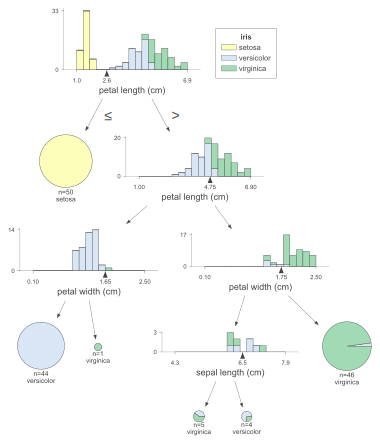

In [87]:
import dtreeviz

viz_model = dtreeviz.model(classifier,
                           X_train=x, y_train=y,
                           feature_names=iris.feature_names,
                           target_name='iris',
                           class_names=iris.target_names)

viz_model.view()

In [88]:
viz = viz_model.view()
viz.save("decision_tree_flow.svg") 

#### Set Attachment Fact

In [89]:
watsonx_ai_model.set_attachment_fact(file_to_upload="decision_tree_flow.svg", description="Decision tree flow",phase_name = "validate", fact_id="decision_tree_flow")

2026/03/24 09:06:16 WARNING : The 'phase_name' parameter no longer needs to be provided in the Python SDK. The lifecycle phase is now determined automatically by the backend. The parameter is ignored and should be removed from existing code. Support for the parameter will be removed in a future release.
2026/03/24 09:06:40 INFO : Successfully uploaded file decision_tree_flow.svg to the factsheet of asset_id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
 
	=== Attachment Details : ===
 * attachment id : 52e9dcd8-e1f1-4d9f-8aa9-ea04fb27d616
 * asset type : modelfacts_user
 * attachment name : decision_tree_flow.svg 
 * description : Decision tree flow
 * MIME type : image/svg xml
 * attachment size : 179929 bytes


#### <span style="color: gold;">Example2:</span> Horizontal view of decision flow

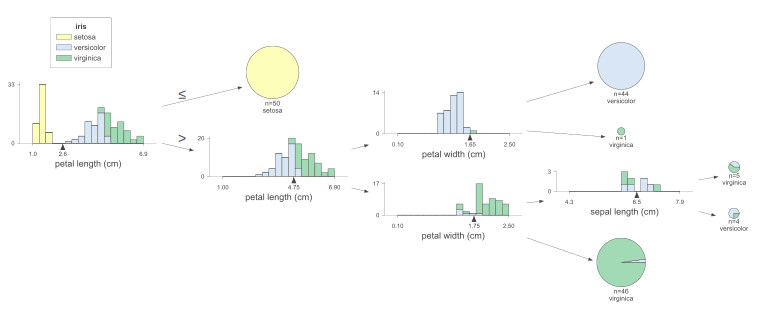

In [90]:
viz_model.view(orientation="LR")

In [91]:
viz = viz_model.view()
viz.save("decision_tree_horizontal_flow.svg") 

#### Set Attachment Fact

In [92]:
watsonx_ai_model.set_attachment_fact(file_to_upload="decision_tree_horizontal_flow.svg", description="Decision tree horizontal flow", phase_name = "validate",fact_id="sample_id_test")

2026/03/24 09:06:42 WARNING : The 'phase_name' parameter no longer needs to be provided in the Python SDK. The lifecycle phase is now determined automatically by the backend. The parameter is ignored and should be removed from existing code. Support for the parameter will be removed in a future release.
2026/03/24 09:07:06 INFO : Successfully uploaded file decision_tree_horizontal_flow.svg to the factsheet of asset_id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
 
	=== Attachment Details : ===
 * attachment id : acb4d721-6c0d-4127-ad24-ea3ffb25cccb
 * asset type : modelfacts_user
 * attachment name : decision_tree_horizontal_flow.svg 
 * description : Decision tree horizontal flow
 * MIME type : image/svg xml
 * attachment size : 179929 bytes


### List All Attachments for a Model <a name="attachmentlist"></a>

This section provides a detailed list of all attachments associated with a specific model. Attachments can include various files such as images, documents, and other relevant resources.


In [93]:
watsonx_ai_model.list_attachments()

[{'attachment_id': '81e110c5-2d36-431e-99d2-f453185c63de',
  'description': 'Confusion Metrix',
  'name': 'confusion_matrix.png',
  'mime': 'image/png',
  'fact_id': 'sample__icokeo',
  'phase_name': 'develop'},
 {'attachment_id': '86685a30-29d2-4cc3-9823-a96735b55432',
  'description': 'Confusion Metrix',
  'name': 'confusion_matrix.png',
  'mime': 'image/png',
  'fact_id': 'metrix_exist',
  'phase_name': 'develop'},
 {'attachment_id': '52e9dcd8-e1f1-4d9f-8aa9-ea04fb27d616',
  'description': 'Decision tree flow',
  'name': 'decision_tree_flow.svg',
  'mime': 'image/svg xml',
  'fact_id': 'decision_tree_flow',
  'phase_name': 'develop'},
 {'attachment_id': 'acb4d721-6c0d-4127-ad24-ea3ffb25cccb',
  'description': 'Decision tree horizontal flow',
  'name': 'decision_tree_horizontal_flow.svg',
  'mime': 'image/svg xml',
  'fact_id': 'sample_id_test',
  'phase_name': 'develop'}]

### Remove Attachments <a name="attachmentremove"></a>

This section guides you through the process of removing attachments from a model. You can delete any unnecessary or outdated files to keep your model organized and up-to-date.


In [94]:
watsonx_ai_model.remove_attachment(fact_id="sample_id_test")

2026/03/24 09:07:21 INFO : Deleted attachment for fact id: sample_id_test successfully


#### -> Remove all attachments
Use this option to delete all attachments associated with the model. This action is irreversible, so ensure that you really want to remove all files before proceeding.


In [95]:
watsonx_ai_model.remove_all_attachments()

2026/03/24 09:07:29 INFO : Deleted attachment id 81e110c5-2d36-431e-99d2-f453185c63de successfully
2026/03/24 09:07:33 INFO : Deleted attachment id 86685a30-29d2-4cc3-9823-a96735b55432 successfully
2026/03/24 09:07:38 INFO : Deleted attachment id 52e9dcd8-e1f1-4d9f-8aa9-ea04fb27d616 successfully
2026/03/24 09:07:38 INFO : All attachments deleted successfully


## <span style="color:gold;"> AI usecase</span>

For more information, refer to the [AI usecase Attachment documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model%20Usecase/Model%20Usecase%20Attachments.html)






#### Retrieve Attachment Definitions for AI usecase

Displays all attachment fact definitions for a AI usecase, providing an overview of the available attachment types and their associated details.







In [96]:
facts_client.assets.get_attachment_definitions(type_name="model_usecase")

2026/03/24 09:07:40 INFO : Attachment fact definitions retrieved successfully
type: model_usecase
      **group**:

      -- name: Zero Index Group Model usecase
      -- id: zero_group_id_model_usecase
      -- description: Group for creating model use case attachment facts directly

      **group**:

      -- name: usecase grp1
      -- id: usecase_grp_rcffvz
      -- description: 

            **facts**:

           -- name: uc f1 edit
           -- id: uc_f_hezvjj
           -- description: 
           -- arrangement_order_id: 1




#### Set Attachment Fact

Sets an attachment fact for a given AI usecase



In [97]:
ai_usecase.set_attachment_fact(file_to_upload="/Users/tharayasmin/Documents/confusion_matrix.png", description="Confusion Metrix", fact_id="sample_id_test")

2026/03/24 09:07:45 INFO : Successfully uploaded file /Users/tharayasmin/Documents/confusion_matrix.jpg to the factsheet of asset_id 47ae541c-d01a-4955-8670-836c1369601c
 
	=== Attachment Details : ===
 * attachment id : e38751e1-3e80-46b7-a633-f5a70edbdfbe
 * asset type : model_entry_user
 * attachment name : confusion_matrix.png 
 * description : Confusion Metrix
 * MIME type : image/png
 * attachment size : 6750 bytes


#### Handling Non-Existent `fact_id`

If the specified `fact_id` does not exist, the attachment will be added under the "Other Attachments" section. 

This ensures that all attachments are categorized, even when the `fact_id` is new or undefined.



In [98]:
ai_usecase.set_attachment_fact(file_to_upload="/Users/tharayasmin/Documents/confusion_matrix.png", description="Confusion Metrix", fact_id="metrix_exist")

2026/03/24 09:07:54 INFO : Successfully uploaded file /Users/tharayasmin/Documents/confusion_matrix.jpg to the factsheet of asset_id 47ae541c-d01a-4955-8670-836c1369601c
 
	=== Attachment Details : ===
 * attachment id : 09f42f65-dfea-402a-8410-2b9a79e9c566
 * asset type : model_entry_user
 * attachment name : confusion_matrix.png 
 * description : Confusion Metrix
 * MIME type : image/png
 * attachment size : 6750 bytes


#### Verify Existing Attachments for `fact_id`

Checks if the specified `fact_id` already has associated attachments. 

This ensures that you can determine whether an attachment is already linked to the given `fact_id` before adding new ones.



In [99]:
ai_usecase.has_attachment(fact_id="sample_id_test")

True

### List All Attachments for a  AI usecase <a name="attachmentlist"></a>

This section provides a detailed list of all attachments associated with a specific AI usecase. Attachments can include various files such as images, documents, and other relevant resources.


In [100]:
ai_usecase.list_attachments()

[{'attachment_id': 'e38751e1-3e80-46b7-a633-f5a70edbdfbe',
  'description': 'Confusion Metrix',
  'name': 'confusion_matrix.png',
  'mime': 'image/png',
  'fact_id': 'sample_id_test'},
 {'attachment_id': '09f42f65-dfea-402a-8410-2b9a79e9c566',
  'description': 'Confusion Metrix',
  'name': 'confusion_matrix.png',
  'mime': 'image/png',
  'fact_id': 'metrix_exist'}]

### Remove Attachments <a name="attachmentremove"></a>

This section guides you through the process of removing attachments from a AI usecase. You can delete any unnecessary or outdated files to keep your AI usecase organized and up-to-date.


In [101]:
ai_usecase.remove_attachment(fact_id="sample_id_test")

2026/03/24 09:08:18 INFO : Deleted attachment for fact id: sample_id_test successfully


#### -> Remove all attachments
Use this option to delete all attachments associated with the AI usecase. This action is irreversible, so ensure that you really want to remove all files before proceeding.


In [102]:
ai_usecase.remove_all_attachments()

2026/03/24 09:08:23 INFO : Deleted attachment id 09f42f65-dfea-402a-8410-2b9a79e9c566 successfully
2026/03/24 09:08:23 INFO : All attachments deleted successfully


---
## Cell Facts <a name="cellfacts"></a>

- **Automatic Output Capture**: Cell Facts automatically capture outputs from a cell, including print statements, tables, and images. It handles various types of content seamlessly.
  
- **HTML Conversion**: The captured outputs are converted into HTML snippet files. This conversion includes all text, tables, and images from the cell.

- **Attachment Support**: HTML snippet files can be uploaded as attachments. These files can be accessed later through the user interface.

- **User Interface Display**: In the user interface, these HTML files appear as clickable attachments. Users can view the content by clicking on these attachments.

- **Inline Report Rendering**: When included in reports, the HTML is rendered inline. This means that tables and other elements are displayed directly within the report, with proper formatting.

- **No Manual Saving Required**: There is no need for manual code to save outputs to files. Cell Facts automate this process, making it more efficient and less error-prone.




## <span style="color: gold;"> Model </span>

For more information, refer to the [Model Cell facts documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model/cell_facts_model.html)

#### Capture Scatter Plot Visualization

The code snippet below creates and captures a scatter plot to visualize the training data for the Iris dataset

This cell captures the scatter plot as an HTML snippet, which can be included in reports or saved as an attachment for further use.

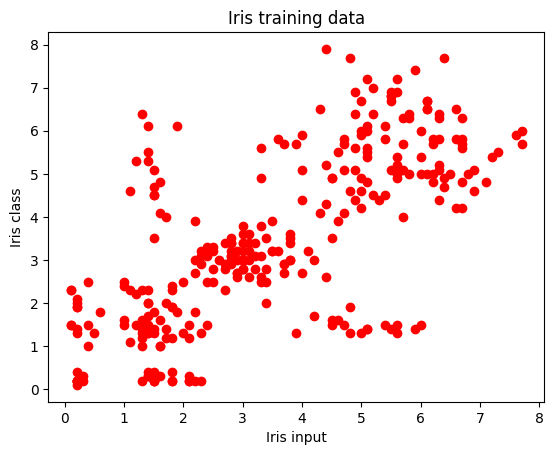

2026/03/24 18:27:25 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_85x.html'

In [109]:
%%capture_cell_facts 
import matplotlib.pyplot as plt
plt.scatter(x_train, x_test, color = 'red')
#plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color = 'blue')
plt.title('Iris training data')
plt.xlabel('Iris input')
plt.ylabel('Iris class')
plt.show()

##### Saving Attachment for Training Data Visualization

> **Alert:** This  `phase` feature is specifically available in version 5.0.1 and subsequent versions. If you are using a version prior to 5.0.1, please remove the `phase` parameter as it is not supported in those versions.


In [110]:
watsonx_ai_model.set_cell_attachment_fact(description="Training data visualization",fact_id="data_distribution",phase_name="develop")

2026/03/24 18:27:31 WARNING : The 'phase_name' parameter no longer needs to be provided in the Python SDK. The lifecycle phase is now determined automatically by the backend. The parameter is ignored and should be removed from existing code. Support for the parameter will be removed in a future release.
2026/03/24 18:27:58 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_85x.html to the factsheet of asset_id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
 
	=== Attachment Details : ===
 * attachment id : dc35c869-e95b-4cdd-8afc-1c35f83cfc1a
 * asset type : modelfacts_user
 * attachment name : Captured_Cell_Output_85x.html 
 * description : Training data visualization
 * MIME type : text/html
 * attachment size : 29194 bytes


#### Capture Print Statements

This section demonstrates how to capture and save print statements from code cells

This cell captures the print statement as an HTML snippet, which can be included in reports or saved as an attachment for further use.

In [111]:
%%capture_cell_facts -po 
# capture print stmt only 

print("Working on Iris data")
print("Model trained")

Working on Iris data
Model trained
2026/03/24 18:27:58 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_e8g.html'

##### Saving Attachment for Print Output


> **Alert:** This  `phase` feature is specifically available in version 5.0.1 and subsequent versions. If you are using a version prior to 5.0.1, please remove the `phase` parameter as it is not supported in those versions.


In [112]:
watsonx_ai_model.set_cell_attachment_fact(description="Print output",fact_id="print_store",phase_name="develop")

2026/03/24 18:27:58 WARNING : The 'phase_name' parameter no longer needs to be provided in the Python SDK. The lifecycle phase is now determined automatically by the backend. The parameter is ignored and should be removed from existing code. Support for the parameter will be removed in a future release.
2026/03/24 18:28:22 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_e8g.html to the factsheet of asset_id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
 
	=== Attachment Details : ===
 * attachment id : d0a07ee8-f035-4f6c-8a8d-4fda714d235c
 * asset type : modelfacts_user
 * attachment name : Captured_Cell_Output_e8g.html 
 * description : Print output
 * MIME type : text/html
 * attachment size : 60 bytes


##### Capture Confusion Matrix

This section demonstrates how to capture and save a confusion matrix from your model's evaluation.

This cell captures the Confusion Matrix as an HTML snippet, which can be included in reports or saved as an attachment for further use.

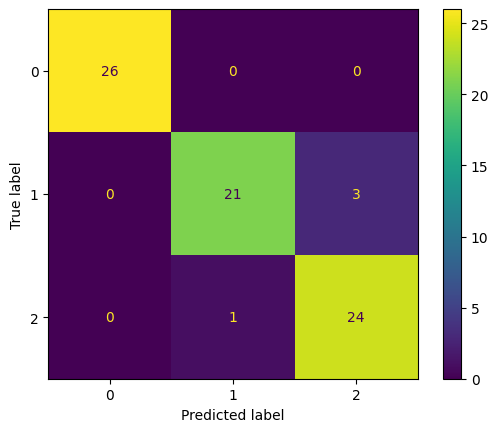

2026/03/24 18:38:44 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_6p6.html'

In [113]:
%%capture_cell_facts 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions1=classifier.predict(x_test)

cm1 = confusion_matrix(y_test, predictions1,labels=classifier.classes_)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1,display_labels=classifier.classes_)
disp1.plot()

plt.show()

##### Saving Attachment for Confusion metrix

> **Alert:** This  `phase` feature is specifically available in version 5.0.1 and subsequent versions. If you are using a version prior to 5.0.1, please remove the `phase` parameter as it is not supported in those versions.




In [114]:
watsonx_ai_model.set_cell_attachment_fact(description="Confusion metrix",fact_id="con_metrix_store",phase_name="develop")

2026/03/24 18:39:08 WARNING : The 'phase_name' parameter no longer needs to be provided in the Python SDK. The lifecycle phase is now determined automatically by the backend. The parameter is ignored and should be removed from existing code. Support for the parameter will be removed in a future release.
2026/03/24 18:39:32 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_6p6.html to the factsheet of asset_id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
 
	=== Attachment Details : ===
 * attachment id : 8efa29bc-fe97-46c6-b0b3-333862bd96c6
 * asset type : modelfacts_user
 * attachment name : Captured_Cell_Output_6p6.html 
 * description : Confusion metrix
 * MIME type : text/html
 * attachment size : 16342 bytes


#### Capture Feature Importance for an Instance

This section demonstrates how to capture feature importance for a specific instance using the `instance_feature_importance()` method

This cell captures the feature importance as an HTML snippet, which can be included in reports or saved as an attachment for further use.


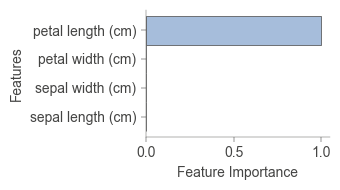

2026/03/24 18:39:35 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_dc0.html'

In [115]:
%%capture_cell_facts

viz_model.instance_feature_importance(y, figsize=(3.5,2))

##### Saving Attachment for Feature importance

> **Alert:** This  `phase` feature is specifically available in version 5.0.1 and subsequent versions. If you are using a version prior to 5.0.1, please remove the `phase` parameter as it is not supported in those versions.



In [116]:
watsonx_ai_model.set_cell_attachment_fact(description="Feature importance",fact_id="feature_importance_fact_id",phase_name="develop")

2026/03/24 18:39:40 WARNING : The 'phase_name' parameter no longer needs to be provided in the Python SDK. The lifecycle phase is now determined automatically by the backend. The parameter is ignored and should be removed from existing code. Support for the parameter will be removed in a future release.
2026/03/24 18:40:03 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_dc0.html to the factsheet of asset_id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
 
	=== Attachment Details : ===
 * attachment id : ac52a241-5c5f-4745-904e-5ac907b6ab6b
 * asset type : modelfacts_user
 * attachment name : Captured_Cell_Output_dc0.html 
 * description : Feature importance
 * MIME type : text/html
 * attachment size : 16018 bytes


### Capture Statistics


This section demonstrates how to capture and visualize statistics for data analysis

This cell captures the statistics as an HTML snippet, which can be included in reports or saved as an attachment for further use.

In [117]:
%%capture_cell_facts

viz_model.node_stats(node_id=6)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,55.0,55.0,55.0,55.0
mean,6.601818,2.972727,5.501818,1.983636
std,0.577508,0.312371,0.547212,0.297373
min,5.6,2.2,4.8,1.4
25%,6.25,2.8,5.1,1.8
50%,6.5,3.0,5.5,2.0
75%,6.9,3.15,5.8,2.25
max,7.9,3.8,6.9,2.5


2026/03/24 18:40:03 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_uvj.html'

##### Saving Attachment for Data statistics

> **Alert:** This  `phase` feature is specifically available in version 5.0.1 and subsequent versions. If you are using a version prior to 5.0.1, please remove the `phase` parameter as it is not supported in those versions.



In [118]:
time.sleep(4)

watsonx_ai_model.set_cell_attachment_fact(description="Data statistics",fact_id="data_stat_fact_id",phase_name="develop")

2026/03/24 18:40:07 WARNING : The 'phase_name' parameter no longer needs to be provided in the Python SDK. The lifecycle phase is now determined automatically by the backend. The parameter is ignored and should be removed from existing code. Support for the parameter will be removed in a future release.
2026/03/24 18:40:32 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_uvj.html to the factsheet of asset_id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9
 
	=== Attachment Details : ===
 * attachment id : c2ed836a-4ec5-4ebc-9a2f-b0bf128b1b04
 * asset type : modelfacts_user
 * attachment name : Captured_Cell_Output_uvj.html 
 * description : Data statistics
 * MIME type : text/html
 * attachment size : 1184 bytes


#### List all attachments for a model

In [119]:
watsonx_ai_model.list_attachments()

[{'attachment_id': 'dc35c869-e95b-4cdd-8afc-1c35f83cfc1a',
  'description': 'Training data visualization',
  'name': 'Captured_Cell_Output_85x.html',
  'mime': 'text/html',
  'fact_id': 'data_distribution',
  'phase_name': 'develop'},
 {'attachment_id': 'd0a07ee8-f035-4f6c-8a8d-4fda714d235c',
  'description': 'Print output',
  'name': 'Captured_Cell_Output_e8g.html',
  'mime': 'text/html',
  'fact_id': 'print_store',
  'phase_name': 'develop'},
 {'attachment_id': '8efa29bc-fe97-46c6-b0b3-333862bd96c6',
  'description': 'Confusion metrix',
  'name': 'Captured_Cell_Output_6p6.html',
  'mime': 'text/html',
  'fact_id': 'con_metrix_store',
  'phase_name': 'develop'},
 {'attachment_id': 'ac52a241-5c5f-4745-904e-5ac907b6ab6b',
  'description': 'Feature importance',
  'name': 'Captured_Cell_Output_dc0.html',
  'mime': 'text/html',
  'fact_id': 'feature_importance_fact_id',
  'phase_name': 'develop'},
 {'attachment_id': 'c2ed836a-4ec5-4ebc-9a2f-b0bf128b1b04',
  'description': 'Data statistics'

## <span style="color: gold;"> AI usecase </span>

For more information, refer to the [AI usecase Cell facts documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model%20Usecase/cell%20facts.html)

#### Capture Scatter Plot Visualization

The code snippet below creates and captures a scatter plot to visualize the training data for the Iris dataset

This cell captures the scatter plot as an HTML snippet, which can be included in reports or saved as an attachment for further use.

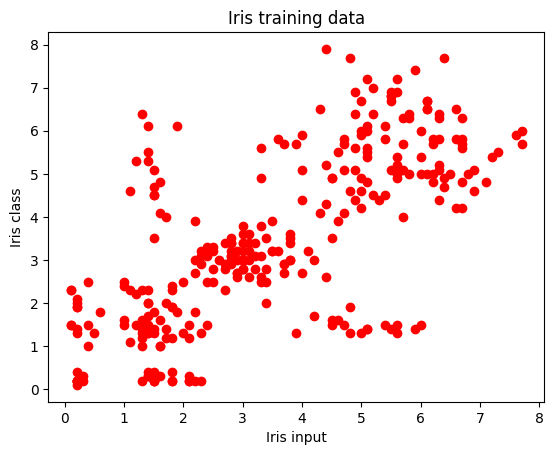

2026/03/24 18:40:36 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_4ok.html'

In [120]:
%%capture_cell_facts 

plt.scatter(x_train, x_test, color = 'red')
#plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color = 'blue')
plt.title('Iris training data')
plt.xlabel('Iris input')
plt.ylabel('Iris class')
plt.show()

##### Saving Attachment for Training Data Visualization

In [121]:
time.sleep(4)

ai_usecase.set_cell_attachment_fact(description="Training data visualization",fact_id="data_distribution")

2026/03/24 18:40:46 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_4ok.html to the factsheet of asset_id 47ae541c-d01a-4955-8670-836c1369601c
 
	=== Attachment Details : ===
 * attachment id : 1b393785-df4a-4f3c-98be-e048e42622d3
 * asset type : model_entry_user
 * attachment name : Captured_Cell_Output_4ok.html 
 * description : Training data visualization
 * MIME type : text/html
 * attachment size : 29194 bytes


#### Capture Print Statements

This section demonstrates how to capture and save print statements from code cells

This cell captures the print statement as an HTML snippet, which can be included in reports or saved as an attachment for further use.

In [122]:
%%capture_cell_facts -po 
# capture print stmt only 

print("Working on Iris data")
print("Model trained")

Working on Iris data
Model trained
2026/03/24 18:42:03 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_g37.html'

##### Saving Attachment for Print Output


In [123]:
ai_usecase.set_cell_attachment_fact(description="Print output",fact_id="print_store")

2026/03/24 18:42:11 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_g37.html to the factsheet of asset_id 47ae541c-d01a-4955-8670-836c1369601c
 
	=== Attachment Details : ===
 * attachment id : d7c6f183-1af8-4e97-9226-e1f4be715054
 * asset type : model_entry_user
 * attachment name : Captured_Cell_Output_g37.html 
 * description : Print output
 * MIME type : text/html
 * attachment size : 60 bytes


##### Capture Confusion Matrix

This section demonstrates how to capture and save a confusion matrix from your model's evaluation.

This cell captures the Confusion Matrix as an HTML snippet, which can be included in reports or saved as an attachment for further use.

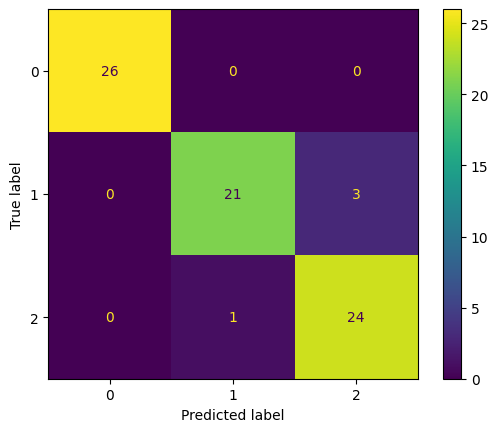

2026/03/24 18:42:15 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_qf4.html'

In [124]:
%%capture_cell_facts 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions1=classifier.predict(x_test)

cm1 = confusion_matrix(y_test, predictions1,labels=classifier.classes_)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1,display_labels=classifier.classes_)
disp1.plot()

plt.show()

##### Saving Attachment for Confusion metrix

In [125]:
time.sleep(2)

ai_usecase.set_cell_attachment_fact(description="Confusion metrix",fact_id="con_metrix_store")

2026/03/24 18:42:24 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_qf4.html to the factsheet of asset_id 47ae541c-d01a-4955-8670-836c1369601c
 
	=== Attachment Details : ===
 * attachment id : 6c4175cf-10ca-4cd7-a58b-db67afae0cb7
 * asset type : model_entry_user
 * attachment name : Captured_Cell_Output_qf4.html 
 * description : Confusion metrix
 * MIME type : text/html
 * attachment size : 16342 bytes


#### Capture Feature Importance for an Instance

This section demonstrates how to capture feature importance for a specific instance using the `instance_feature_importance()` method

This cell captures the feature importance as an HTML snippet, which can be included in reports or saved as an attachment for further use.


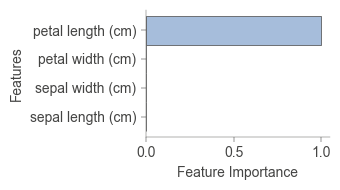

2026/03/24 18:42:38 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_9m7.html'

In [126]:
%%capture_cell_facts

viz_model.instance_feature_importance(y, figsize=(3.5,2))

##### Saving Attachment for Feature importance

In [127]:
time.sleep(4)

ai_usecase.set_cell_attachment_fact(description="Feature importance",fact_id="feature_importance_fact_id")

2026/03/24 18:42:50 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_9m7.html to the factsheet of asset_id 47ae541c-d01a-4955-8670-836c1369601c
 
	=== Attachment Details : ===
 * attachment id : bd5b4a65-7494-4e1d-a601-e593ae2fdd75
 * asset type : model_entry_user
 * attachment name : Captured_Cell_Output_9m7.html 
 * description : Feature importance
 * MIME type : text/html
 * attachment size : 16018 bytes


### Capture Statistics


This section demonstrates how to capture and visualize statistics for data analysis

This cell captures the statistics as an HTML snippet, which can be included in reports or saved as an attachment for further use.

In [128]:
%%capture_cell_facts

viz_model.node_stats(node_id=6)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,55.0,55.0,55.0,55.0
mean,6.601818,2.972727,5.501818,1.983636
std,0.577508,0.312371,0.547212,0.297373
min,5.6,2.2,4.8,1.4
25%,6.25,2.8,5.1,1.8
50%,6.5,3.0,5.5,2.0
75%,6.9,3.15,5.8,2.25
max,7.9,3.8,6.9,2.5


2026/03/24 18:42:50 INFO : Saved cell facts under: 


'/Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_t0c.html'

##### Saving Attachment for Data statistics

In [129]:
time.sleep(4)

ai_usecase.set_cell_attachment_fact(description="Data statistics",fact_id="data_stat_fact_id")

2026/03/24 18:42:59 INFO : Successfully uploaded file /Users/tharayasmin/Documents/ai-governance-factsheet-samples1/Untitled/cloud_pak_for_data/5.3x Version/End To End Flow/captured_cell_facts/Captured_Cell_Output_t0c.html to the factsheet of asset_id 47ae541c-d01a-4955-8670-836c1369601c
 
	=== Attachment Details : ===
 * attachment id : 2affb5ea-37b5-49ce-8fb5-2f9cee05e5c9
 * asset type : model_entry_user
 * attachment name : Captured_Cell_Output_t0c.html 
 * description : Data statistics
 * MIME type : text/html
 * attachment size : 1184 bytes


#### List all attachments for a AI usecase

In [130]:
ai_usecase.list_attachments()

[{'attachment_id': '1b393785-df4a-4f3c-98be-e048e42622d3',
  'description': 'Training data visualization',
  'name': 'Captured_Cell_Output_4ok.html',
  'mime': 'text/html',
  'fact_id': 'data_distribution'},
 {'attachment_id': 'd7c6f183-1af8-4e97-9226-e1f4be715054',
  'description': 'Print output',
  'name': 'Captured_Cell_Output_g37.html',
  'mime': 'text/html',
  'fact_id': 'print_store'},
 {'attachment_id': '6c4175cf-10ca-4cd7-a58b-db67afae0cb7',
  'description': 'Confusion metrix',
  'name': 'Captured_Cell_Output_qf4.html',
  'mime': 'text/html',
  'fact_id': 'con_metrix_store'},
 {'attachment_id': 'bd5b4a65-7494-4e1d-a601-e593ae2fdd75',
  'description': 'Feature importance',
  'name': 'Captured_Cell_Output_9m7.html',
  'mime': 'text/html',
  'fact_id': 'feature_importance_fact_id'},
 {'attachment_id': '2affb5ea-37b5-49ce-8fb5-2f9cee05e5c9',
  'description': 'Data statistics',
  'name': 'Captured_Cell_Output_t0c.html',
  'mime': 'text/html',
  'fact_id': 'data_stat_fact_id'}]

---
## Create an Approach <a href="#createapproach"></a>

- Track multiple models and prompts under a single use case by grouping them into different approaches.
- Create multiple approaches for various classification algorithms to facilitate comparison and integration.
- Use approaches to manage different models that need to be combined for a specific use case.



For more information, refer to the [Approach Documentation](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/asset_model/Model%20Usecase/Model%20Usecase%20Approach.html)


In [131]:
iris_approach =ai_usecase.create_approach(name="Iris classification",description="approach for iris data",icon="Sprout",color="Teal")
iris_approach.get_info()

2026/03/24 18:43:19 INFO : Approach created successfully


{'approach_id': '702a1d91-b59a-4460-9284-adf942d3cc7c',
 'approach_name': 'Iris classification',
 'approach_desc': 'approach for iris data',
 'model_asset_id': '47ae541c-d01a-4955-8670-836c1369601c',
 'model_container_type': 'catalog',
 'model_container_id': '7014d629-4e63-4687-a0e4-a3e533d46ff9'}

---
## Track a Model Under an AI Use Case <a name="add_mu"></a>

- **AI Use Cases** are designed to monitor the lifecycle of model assets across various stages, including development, pre-production, and production.
- To effectively integrate a model into an AI use case, three critical elements must be addressed: the **model**, the **AI use case**, and the **approach**.
- Link an existing AI use case by using the following method: `model.track(usecase=<ai_usecase>, approach=<approach1>, version_number="<Version Number>")`.

- **Version Numbers** are categorized as follows:
    - **Major Version:** Indicates significant changes, represented as `1.0.0`.
    - **Minor Version:** Reflects incremental improvements, represented as `0.1.0`.
    - **Patch Version:** Denotes minor fixes or updates, represented as `0.0.1`.
    - **Custom Version:** Allows for tailored versioning according to specific user needs.

- Ensure that the `ai_usecase`, `approach`, and `version_number` parameters are provided as mandatory.


For more information, refer to the [Governing AI Assets](https://s3.us.cloud-object-storage.appdomain.cloud/aifactsheets-client/doc_files/AIGov/Tracking%20models%20with%20AI%20Factsheets.html)


In [ ]:
watsonx_ai_model.track(usecase=ai_usecase,approach=iris_approach,version_number="major",version_comment="major update to previous version")

#### Retrieve Tracked Models for Use Case

- Fetch all models that are currently tracked under a specified AI use case.
- This provides an overview of all models associated with the use case, facilitating management and analysis.


In [ ]:
ai_usecase.get_tracked_models()

[{'id': '9c39b81e-a501-4f89-85f5-21c08afb6a76',
  'name': 'Iris Watsonx-ai Model',
  'description': '',
  'type': 'wml_model',
  'container_id': '544caa9f-82a5-4f5c-900e-db36097cc71e',
  'container_name': 'task_cred_frankfurt',
  'container_type': 'project',
  'is_deleted': False,
  'master_id': '9c39b81e-a501-4f89-85f5-21c08afb6a76',
  'model_identity_key': 'c5e43112-89e1-47d1-a4d8-20ef17018098',
  'source_asset_id': '',
  'algorithm': '',
  'version_details': {'number': '1.0.0',
   'comment': 'major update to previous version',
   'approach_id': '1c9e2584-9c90-4afa-b6cd-4fb4c3a70500'}}]

---
## Untrack a Model

Remove a model from an AI use case when it is no longer relevant or needs to be managed separately.


In [ ]:
watsonx_ai_model.untrack()

2024/08/09 21:01:05 INFO : Successfully finished unregistering WKC Model 9c39b81e-a501-4f89-85f5-21c08afb6a76 from model use case.


---
## Cleanup<a href="#clean"></a>

In [133]:
if run_cleanup_at_end:
    facts_client.assets.remove_asset(asset_id=ai_usecase.get_info()["model_usecase_id"],container_type=ai_usecase.get_info()["container_type"],container_id=ai_usecase.get_info()["catalog_id"])
    facts_client.assets.remove_asset(asset_id=watsonx_ai_model.get_info()["asset_id"],container_type=watsonx_ai_model.get_info()["container_type"],container_id=watsonx_ai_model.get_info()["container_id"])
    inventory.delete_inventory()

else:
    
    model_ui_url = watsonx_ai_model.get_info(verbose=True)["url"]
    display(Markdown("[Click here to see the created wml model details in UI](" + model_ui_url + ")"))
    model_usecase_ui_url = ai_usecase.get_info(verbose=True)["url"]
    display(Markdown("[Click here to see the created model use case in UI](" + model_usecase_ui_url + ")"))

2026/03/24 18:43:43 INFO : Successfully deleted asset id 47ae541c-d01a-4955-8670-836c1369601c in catalog 7014d629-4e63-4687-a0e4-a3e533d46ff9
2026/03/24 18:43:47 INFO : Successfully deleted asset id c10b1792-c891-4f6c-b72d-7b7b0eaa5cf9 in project 5a9854a6-04ed-4f52-a464-d75d04d267c1
-----------------------------------------------------------------------------------------------------------------------------
                                                  Inventory Deletion Started                                                 
-----------------------------------------------------------------------------------------------------------------------------
2026/03/24 18:43:55 INFO : No assets found in inventory '7014d629-4e63-4687-a0e4-a3e533d46ff9'.
2026/03/24 18:44:08 INFO : Inventory with ID '7014d629-4e63-4687-a0e4-a3e533d46ff9' has been successfully deleted.


**Created by:**  


IBM watsonx.governance - *AI Factsheet Python SDK Team*

---

**Copyright © 2024 IBM**  
Released under the [Apache 2.0 License](https://www.apache.org/licenses/LICENSE-2.0).
